In [335]:
import numpy as np
import pandas as pd
import netwulf as nw
import networkx as nx
import matplotlib.pyplot as plt

In [336]:
pd.set_option('display.max_rows', 500)

In [337]:
connection_pd = pd.read_csv('./raw/line_station_connectionV1130.csv')
connection_pd

,line_cd,station_cd1,station_cd2,company_cd,line_name,station_name1,station_name2,station_lng1,station_lng2,station_lat1,station_lat2,dc:title,odpt:lineCode,odpt:operator,line,odpt_railway,Con,distance
0,11302,1194,976,2,JR山手線,大崎,五反田,139.728439,139.723822,35.619772,35.625974,山手線,JY,odpt.Operator:JR-East,JR-East.Yamanote,odpt.Railway,1,0.735128
1,11302,976,1661,2,JR山手線,五反田,目黒,139.723822,139.715775,35.625974,35.633923,山手線,JY,odpt.Operator:JR-East,JR-East.Yamanote,odpt.Railway,1,1.120418
2,11302,1661,1885,2,JR山手線,目黒,恵比寿,139.715775,139.710070,35.633923,35.646685,山手線,JY,odpt.Operator:JR-East,JR-East.Yamanote,odpt.Railway,1,1.254671
3,11302,1885,725,2,JR山手線,恵比寿,渋谷,139.710070,139.701238,35.646685,35.658871,山手線,JY,odpt.Operator:JR-East,JR-East.Yamanote,odpt.Railway,1,1.425703
4,11302,725,1663,2,JR山手線,渋谷,原宿,139.701238,139.702592,35.658871,35.670646,山手線,JY,odpt.Operator:JR-East,JR-East.Yamanote,odpt.Railway,1,1.009891
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1489,99343,524,889,130,グリーンライン,センター北,北山田,139.578386,139.592258,35.553534,35.561077,グリーンライン,G,odpt.Operator:YokohamaMunicipal,YokohamaMunicipal.Green,odpt.Railway,1,1.669461
1490,99343,889,1714,130,グリーンライン,北山田,東山田,139.592258,139.604369,35.561077,35.554302,グリーンライン,G,odpt.Operator:YokohamaMunicipal,YokohamaMunicipal.Green,odpt.Railway,1,1.463786
1491,99343,1714,674,130,グリーンライン,東山田,高田,139.604369,139.619944,35.554302,35.549713,グリーンライン,G,odpt.Operator:YokohamaMunicipal,YokohamaMunicipal.Green,odpt.Railway,1,1.774937
1492,99343,674,653,130,グリーンライン,高田,日吉本町,139.619944,139.633554,35.549713,35.549883,グリーンライン,G,odpt.Operator:YokohamaMunicipal,YokohamaMunicipal.Green,odpt.Railway,1,1.513431


In [338]:
# list of all the stations in the connection data

station_list_connection_1 = connection_pd[['station_cd1', 'station_name1']].rename(columns={'station_cd1': 'station_id', 'station_name1': 'S12_001'}).drop_duplicates()
station_list_connection_2 = connection_pd[['station_cd2', 'station_name2']].rename(columns={'station_cd2': 'station_id', 'station_name2': 'S12_001'}).drop_duplicates()
station_list_pd = pd.concat([station_list_connection_1, station_list_connection_2]).drop_duplicates().reset_index(drop=True)
station_list_pd

,station_id,S12_001
0,1194,大崎
1,976,五反田
2,1661,目黒
3,1885,恵比寿
4,725,渋谷
...,...,...
1108,424,芝山千代田
1109,1631,松戸
1110,594,羽田空港第2ターミナル
1111,1448,東葉勝田台


In [339]:
# list of all the stations in the passenger survey data that are also in the connection data

passenger_survey_pd = pd.read_csv('./raw/pass_survey_tokyov1109.csv')
passenger_survey_pd['station_id'] = passenger_survey_pd['station_id'].astype(int)
passenger_survey_pd[passenger_survey_pd['station_id'].isin(station_list_pd['station_id'].values)]

matching_passenger_survey_pd = passenger_survey_pd[passenger_survey_pd['station_id'].isin(station_list_pd['station_id'].values)].reset_index(drop=True)
matching_passenger_survey_pd = matching_passenger_survey_pd.sort_values('station_id').reset_index(drop=True)
matching_passenger_survey_pd

year_cols = ['2013', '2014', '2015', '2016', '2017', '2018', '2019']
# max-min normalize passenger counts:

# normalization with global values:
global_min = matching_passenger_survey_pd[year_cols].min().min()
global_max = matching_passenger_survey_pd[year_cols].max().max()
for year in year_cols:
    matching_passenger_survey_pd[year] = (matching_passenger_survey_pd[year] - global_min) / (global_max - global_min)

print("Before normalization:")
print(matching_passenger_survey_pd.loc[matching_passenger_survey_pd['S12_001'] == '渋谷'])
# normalization with row values:
# row_mins = matching_passenger_survey_pd[year_cols].min(axis=1)
# row_maxs = matching_passenger_survey_pd[year_cols].max(axis=1)
# for year in year_cols:
#     matching_passenger_survey_pd[year] = (matching_passenger_survey_pd[year] - row_mins) / (row_maxs - row_mins)


Before normalization:
    S12_001      2013      2014      2015      2016      2017      2018  \
320      渋谷  0.586972  0.571573  0.578823  0.581368  0.589753  0.591181   

         2019  station_id  
320  0.640074         725  


In [374]:
#find all the full 0 rows in the year columns
full_zero_rows = matching_passenger_survey_pd[year_cols].apply(lambda row: (row == 0).all(), axis=1)
matching_passenger_survey_pd[full_zero_rows]
# print(matching_passenger_survey_pd.loc[matching_passenger_survey_pd['S12_001'] == '渋谷'])

,station_id,S12_001,2013,2014,2015,2016,2017,2018,2019
28,699,高輪ゲートウェイ,0.0,0.0,0.0,0.0,0.0,0.0,0.0
58,1012,小田栄,0.0,0.0,0.0,0.0,0.0,0.0,0.0
59,1620,浜川崎,0.0,0.0,0.0,0.0,0.0,0.0,0.0
61,364,国道,0.0,0.0,0.0,0.0,0.0,0.0,0.0
62,2328,鶴見小野,0.0,0.0,0.0,0.0,0.0,0.0,0.0
63,267,弁天橋,0.0,0.0,0.0,0.0,0.0,0.0,0.0
64,1662,浅野,0.0,0.0,0.0,0.0,0.0,0.0,0.0
65,824,新芝浦,0.0,0.0,0.0,0.0,0.0,0.0,0.0
66,2209,安善,0.0,0.0,0.0,0.0,0.0,0.0,0.0
67,1404,海芝浦,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [341]:
# matching_passenger_survey_pd = matching_passenger_survey_pd[~full_zero_rows].reset_index(drop=True)
# matching_passenger_survey_pd
row_mins = matching_passenger_survey_pd[year_cols].min(axis=1)
row_maxs = matching_passenger_survey_pd[year_cols].max(axis=1)

In [342]:
# and now we need to make sure nodes in the passenger survey match up with nodes in the connection data
# the passenger_survey_pd only has nodes that are in the station_list_pd, so we can just filter the station_list_pd to only include those nodes

# note that both data had stations that were not in the other

station_list_pd = station_list_pd[station_list_pd['station_id'].isin(matching_passenger_survey_pd['station_id'].values)].reset_index(drop=True)
station_list_pd = station_list_pd.sort_values('station_id').reset_index(drop=True)
station_list_pd

,station_id,S12_001
0,2,霞ヶ関
1,3,多摩湖
2,4,高島町
3,7,志村三丁目
4,9,印西牧の原
...,...,...
1101,2491,吉川美南
1102,2492,富水
1103,2493,東福生
1104,2494,中井


In [375]:
connection_pd

,line_cd,station_cd1,station_cd2,company_cd,line_name,station_name1,station_name2,station_lng1,station_lng2,station_lat1,station_lat2,dc:title,odpt:lineCode,odpt:operator,line,odpt_railway,Con,distance
0,11302,1194,976,2,JR山手線,大崎,五反田,139.728439,139.723822,35.619772,35.625974,山手線,JY,odpt.Operator:JR-East,JR-East.Yamanote,odpt.Railway,1,0.735128
1,11302,976,1661,2,JR山手線,五反田,目黒,139.723822,139.715775,35.625974,35.633923,山手線,JY,odpt.Operator:JR-East,JR-East.Yamanote,odpt.Railway,1,1.120418
2,11302,1661,1885,2,JR山手線,目黒,恵比寿,139.715775,139.710070,35.633923,35.646685,山手線,JY,odpt.Operator:JR-East,JR-East.Yamanote,odpt.Railway,1,1.254671
3,11302,1885,725,2,JR山手線,恵比寿,渋谷,139.710070,139.701238,35.646685,35.658871,山手線,JY,odpt.Operator:JR-East,JR-East.Yamanote,odpt.Railway,1,1.425703
4,11302,725,1663,2,JR山手線,渋谷,原宿,139.701238,139.702592,35.658871,35.670646,山手線,JY,odpt.Operator:JR-East,JR-East.Yamanote,odpt.Railway,1,1.009891
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1489,99343,524,889,130,グリーンライン,センター北,北山田,139.578386,139.592258,35.553534,35.561077,グリーンライン,G,odpt.Operator:YokohamaMunicipal,YokohamaMunicipal.Green,odpt.Railway,1,1.669461
1490,99343,889,1714,130,グリーンライン,北山田,東山田,139.592258,139.604369,35.561077,35.554302,グリーンライン,G,odpt.Operator:YokohamaMunicipal,YokohamaMunicipal.Green,odpt.Railway,1,1.463786
1491,99343,1714,674,130,グリーンライン,東山田,高田,139.604369,139.619944,35.554302,35.549713,グリーンライン,G,odpt.Operator:YokohamaMunicipal,YokohamaMunicipal.Green,odpt.Railway,1,1.774937
1492,99343,674,653,130,グリーンライン,高田,日吉本町,139.619944,139.633554,35.549713,35.549883,グリーンライン,G,odpt.Operator:YokohamaMunicipal,YokohamaMunicipal.Green,odpt.Railway,1,1.513431


In [ ]:
#remove any connections between stations that are not in the station_list_pd
station_node_pd = connection_pd[connection_pd['station_cd1'].isin(station_list_pd['station_id'].values) & connection_pd['station_cd2'].isin(station_list_pd['station_id'].values)][['line', 'station_cd1', 'station_cd2', 'distance']].drop_duplicates()
station_node_pd

,line,station_cd1,station_cd2,distance
0,JR-East.Yamanote,1194,976,0.735128
1,JR-East.Yamanote,976,1661,1.120418
2,JR-East.Yamanote,1661,1885,1.254671
3,JR-East.Yamanote,1885,725,1.425703
4,JR-East.Yamanote,725,1663,1.009891
...,...,...,...,...
1489,YokohamaMunicipal.Green,524,889,1.669461
1490,YokohamaMunicipal.Green,889,1714,1.463786
1491,YokohamaMunicipal.Green,1714,674,1.774937
1492,YokohamaMunicipal.Green,674,653,1.513431


In [344]:
# testing:

first_row = station_node_pd.loc[(station_node_pd['station_cd1'] == 1194) & (station_node_pd['station_cd2'] == 976)]
second_row = station_node_pd.loc[(station_node_pd['station_cd1'] == 976) & (station_node_pd['station_cd2'] == 1194)]
print(first_row)
print(second_row)

               line  station_cd1  station_cd2  distance
0  JR-East.Yamanote         1194          976  0.735128
Empty DataFrame
Columns: [line, station_cd1, station_cd2, distance]
Index: []


In [345]:
# build graph structure using networkx
G = nx.Graph()
G = nx.from_pandas_edgelist(station_node_pd, 'station_cd1', 'station_cd2', edge_attr=True)

node_order = list(G.nodes())
print(f"Number of nodes in G: {len(G.nodes())}")
print(f"Number of edges in G: {len(G.edges())}")

Number of nodes in G: 1106
Number of edges in G: 1285


In [346]:
# we need to make sure the station_list_pd is in the same order as the nodes in the graph G, which is the order the adjacency matrix will use
station_list_pd = station_list_pd.set_index('station_id').loc[node_order].reset_index(drop=False)
station_list_pd

,station_id,S12_001
0,1194,大崎
1,976,五反田
2,1661,目黒
3,1885,恵比寿
4,725,渋谷
...,...,...
1101,790,都筑ふれあいの丘
1102,889,北山田
1103,1714,東山田
1104,674,高田


In [347]:
# and we also need to make sure the passenger survey data is in the same order as the nodes in the graph G, which is the order the adjacency matrix will use
matching_passenger_survey_pd = matching_passenger_survey_pd.set_index('station_id').loc[node_order].reset_index(drop=False)
matching_passenger_survey_pd

,station_id,S12_001,2013,2014,2015,2016,2017,2018,2019
0,1194,大崎,0.065471,0.067878,0.068955,0.073155,0.076126,0.081956,0.081956
1,976,五反田,0.102623,0.103546,0.104375,0.105332,0.107845,0.111082,0.110915
2,1661,目黒,0.107486,0.109963,0.111805,0.112591,0.117658,0.122312,0.122426
3,1885,恵比寿,0.086440,0.088655,0.090444,0.093605,0.096105,0.098302,0.097795
4,725,渋谷,0.586972,0.571573,0.578823,0.581368,0.589753,0.591181,0.640074
...,...,...,...,...,...,...,...,...,...
1101,790,都筑ふれあいの丘,0.004440,0.004547,0.004773,0.004935,0.004988,0.005171,0.005274
1102,889,北山田,0.005942,0.006103,0.006389,0.006530,0.006657,0.006804,0.006732
1103,1714,東山田,0.002177,0.002218,0.002312,0.002438,0.002495,0.002574,0.002482
1104,674,高田,0.005797,0.005408,0.005997,0.006168,0.006219,0.006478,0.006588


(<Figure size 480x480 with 1 Axes>, <Axes: >)

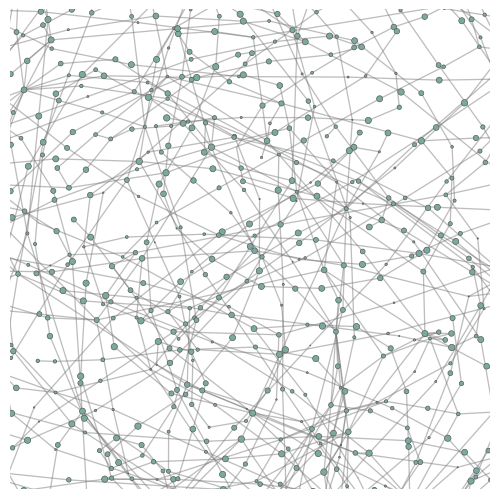

In [348]:
for n, data in G.nodes(data=True):
    data['size'] = np.random.random()

stylized_network, config = nw.visualize(G, plot_in_cell_below=True)

nw.draw_netwulf(stylized_network, config)

In [349]:
#normalize distances
d_max = station_node_pd['distance'].max()
station_node_pd['nor_distance'] = station_node_pd['distance'].apply(lambda x: (x - 0.1) / (d_max - 0.1))
station_node_pd

,line,station_cd1,station_cd2,distance,nor_distance
0,JR-East.Yamanote,1194,976,0.735128,0.048421
1,JR-East.Yamanote,976,1661,1.120418,0.077795
2,JR-East.Yamanote,1661,1885,1.254671,0.088030
3,JR-East.Yamanote,1885,725,1.425703,0.101069
4,JR-East.Yamanote,725,1663,1.009891,0.069368
...,...,...,...,...,...
1489,YokohamaMunicipal.Green,524,889,1.669461,0.119653
1490,YokohamaMunicipal.Green,889,1714,1.463786,0.103972
1491,YokohamaMunicipal.Green,1714,674,1.774937,0.127694
1492,YokohamaMunicipal.Green,674,653,1.513431,0.107757


In [350]:
#get operator name from line name
#TODO this could be redundant, could just directly get operator instead
station_node_pd['operator'] = station_node_pd['line'].apply(lambda x: x.split('.')[0])
station_node_pd

,line,station_cd1,station_cd2,distance,nor_distance,operator
0,JR-East.Yamanote,1194,976,0.735128,0.048421,JR-East
1,JR-East.Yamanote,976,1661,1.120418,0.077795,JR-East
2,JR-East.Yamanote,1661,1885,1.254671,0.088030,JR-East
3,JR-East.Yamanote,1885,725,1.425703,0.101069,JR-East
4,JR-East.Yamanote,725,1663,1.009891,0.069368,JR-East
...,...,...,...,...,...,...
1489,YokohamaMunicipal.Green,524,889,1.669461,0.119653,YokohamaMunicipal
1490,YokohamaMunicipal.Green,889,1714,1.463786,0.103972,YokohamaMunicipal
1491,YokohamaMunicipal.Green,1714,674,1.774937,0.127694,YokohamaMunicipal
1492,YokohamaMunicipal.Green,674,653,1.513431,0.107757,YokohamaMunicipal


In [351]:
#let's color lines by operator

operators_list = station_node_pd['operator'].unique()
operators_list.sort()
print("Operators:", operators_list)

colors = range(len(station_node_pd['operator'].unique()))
N=len(colors)

cmap = plt.get_cmap("Set3_r")
cmap_list=[]
for i in range(N):
    c=cmap(float(i)/N)
    cmap_list.append(c)

line_color=dict(zip(operators_list,cmap_list))

line_color

Operators: ['Hokuso' 'JR-East' 'Keikyu' 'Keio' 'Keisei' 'Minatomirai' 'Odakyu'
 'SaitamaRailway' 'Seibu' 'Shibayama' 'ShinKeisei' 'Sotetsu' 'TWR' 'Tobu'
 'Toei' 'TokyoMetro' 'TokyoMonorail' 'Tokyu' 'ToyoRapid'
 'YokohamaMunicipal' 'Yurikamome']


{'Hokuso': (1.0, 0.9294117647058824, 0.43529411764705883, 1.0),
 'JR-East': (1.0, 0.9294117647058824, 0.43529411764705883, 1.0),
 'Keikyu': (0.8, 0.9215686274509803, 0.7725490196078432, 1.0),
 'Keio': (0.8, 0.9215686274509803, 0.7725490196078432, 1.0),
 'Keisei': (0.7372549019607844, 0.5019607843137255, 0.7411764705882353, 1.0),
 'Minatomirai': (0.7372549019607844,
  0.5019607843137255,
  0.7411764705882353,
  1.0),
 'Odakyu': (0.8509803921568627, 0.8509803921568627, 0.8509803921568627, 1.0),
 'SaitamaRailway': (0.9882352941176471,
  0.803921568627451,
  0.8980392156862745,
  1.0),
 'Seibu': (0.9882352941176471, 0.803921568627451, 0.8980392156862745, 1.0),
 'Shibayama': (0.7019607843137254,
  0.8705882352941177,
  0.4117647058823529,
  1.0),
 'ShinKeisei': (0.7019607843137254,
  0.8705882352941177,
  0.4117647058823529,
  1.0),
 'Sotetsu': (0.9921568627450981, 0.7058823529411765, 0.3843137254901961, 1.0),
 'TWR': (0.9921568627450981, 0.7058823529411765, 0.3843137254901961, 1.0),
 'Tobu

In [352]:
for link in stylized_network['links']:
    
    line = station_node_pd[((station_node_pd['station_cd1'] == link['source']) & (station_node_pd['station_cd2'] == link['target'])) |
                           ((station_node_pd['station_cd1'] == link['target']) & (station_node_pd['station_cd2'] == link['source']))]
    # print(line)
    if len(line) > 0:
        print(line)#operator
        #link['color'] = line_color[line.iloc[0, 4]]
        link['color'] = line_color[line.iloc[0, 5]] # 0 takes the first row and 5 takes the operator column. this is fine since if multiple lines go between two stations just pick one of them for the color
        dis = line.iloc[0, 3]
        if dis < 1.0:
            link['width'] = 5
        elif dis < 2.0:
            link['width'] = 4
        elif dis < 5.0:
            link['width'] = 3
        elif dis < 10.0:
            link['width'] = 2
        else:
            link['width'] = 1
    else:
        print(link)
        # if didn't print link, then all the lines have been found

               line  station_cd1  station_cd2  distance  nor_distance operator
0  JR-East.Yamanote         1194          976  0.735128      0.048421  JR-East
                line  station_cd1  station_cd2  distance  nor_distance  \
28  JR-East.Yamanote         1750         1194  1.400128      0.099119   

   operator  
28  JR-East  
                        line  station_cd1  station_cd2  distance  \
296           JR-East.Saikyo         1194         1885  3.063343   
464   JR-East.ShonanShinjuku         1885         1194  3.063343   
1207        Sotetsu.JRDirect         1885         1194  3.063343   

      nor_distance operator  
296       0.225919  JR-East  
464       0.225919  JR-East  
1207      0.225919  Sotetsu  
                        line  station_cd1  station_cd2  distance  \
465   JR-East.ShonanShinjuku         1194          785  1.711485   
1208        Sotetsu.JRDirect         1194          785  1.711485   

      nor_distance operator  
465       0.122856  JR-East  
1208   

In [353]:
#track stations with no

for node in stylized_network['nodes']:
    sta = passenger_survey_pd[passenger_survey_pd['station_id'] == node['id']] #node id is station name in english
    if sta.shape[0] == 0:
        print(node['id'], sta.shape[0])
    if len(sta) > 0:
        #node['color'] = line_color[station_node_pd[station_node_pd['station_en'] == node['id']].iloc[0, 4]]
        if not station_node_pd[station_node_pd['station_cd1'] == node['id']].empty:
            node['color'] = line_color[station_node_pd[station_node_pd['station_cd1'] == node['id']].iloc[0, 5]]
            sta_mean = sta[['2013', '2014', '2015', '2016', '2017', '2018', '2019']].values.mean()
            if sta_mean < 10000:
                node['radius'] = 1.5
            elif sta_mean < 100000:
                node['radius'] = 2.5
            elif sta_mean < 500000:
                node['radius'] = 4
            elif sta_mean < 1000000:
                node['radius'] = 7
            elif sta_mean < 2000000:
                node['radius'] = 9
            else:
                node['radius'] = 10
        elif not station_node_pd[station_node_pd['station_cd2'] == node['id']].empty: #some stations only appear in station_cd2 column 
            node['color'] = line_color[station_node_pd[station_node_pd['station_cd2'] == node['id']].iloc[0, 5]] 
            sta_mean = sta[['2013', '2014', '2015', '2016', '2017', '2018', '2019']].values.mean()
            if sta_mean < 10000:
                node['radius'] = 1.5
            elif sta_mean < 100000:
                node['radius'] = 2.5
            elif sta_mean < 500000:
                node['radius'] = 4
            elif sta_mean < 1000000:
                node['radius'] = 7
            elif sta_mean < 2000000:
                node['radius'] = 9
            else:
                node['radius'] = 10
    else:
        print("station not found in survey data:", node['id'])
    # highlight major stations in green
    if node['id'] in ['Shibuya', 'Shinjuku', 'Ikebukuro', 'Yokohama', 'Takadanobaba', 'Tokyo', 'Shimbashi', 'Shinagawa']:
        node['color'] = "lawngreen"

for node in stylized_network['nodes']:
    print(node) 
# nw.draw_netwulf(stylized_network, config)

{'id': 1194, 'x': 533.8138968868735, 'y': 686.2482562172121, 'x_canvas': 533.8138968868735, 'y_canvas': 686.2482562172121, 'radius': 4, 'color': (1.0, 0.9294117647058824, 0.43529411764705883, 1.0)}
{'id': 976, 'x': 375.13213291223116, 'y': 624.7270736579964, 'x_canvas': 375.1321329122311, 'y_canvas': 624.7270736579964, 'radius': 4, 'color': (1.0, 0.9294117647058824, 0.43529411764705883, 1.0)}
{'id': 1661, 'x': 450.7387787442589, 'y': 637.7556723746491, 'x_canvas': 450.7387787442589, 'y_canvas': 637.7556723746491, 'radius': 4, 'color': (1.0, 0.9294117647058824, 0.43529411764705883, 1.0)}
{'id': 1885, 'x': 273.9327604552803, 'y': 580.7316116169358, 'x_canvas': 273.9327604552803, 'y_canvas': 580.7316116169358, 'radius': 4, 'color': (1.0, 0.9294117647058824, 0.43529411764705883, 1.0)}
{'id': 725, 'x': 12.39834735205037, 'y': 409.627042729204, 'x_canvas': 12.39834735205037, 'y_canvas': 409.62704272920394, 'radius': 10, 'color': (1.0, 0.9294117647058824, 0.43529411764705883, 1.0)}
{'id': 166

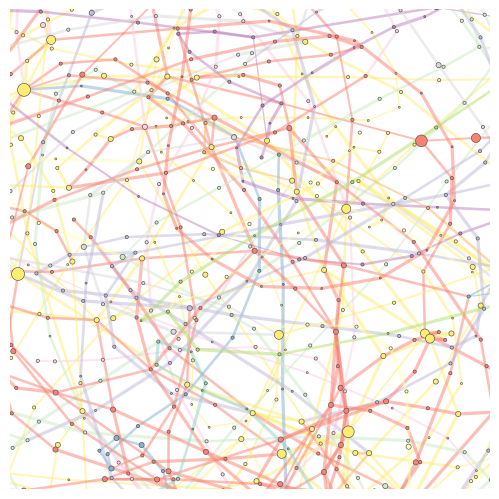

In [354]:
fig, ax = nw.draw_netwulf(stylized_network, config)
plt.show()

In [355]:
print("number of edges:", len(stylized_network['links']))
print("number of nodes:", len(stylized_network['nodes']))
print("passenger count means for stations with more than 500k passengers in 2019:")
for sta in passenger_survey_pd[passenger_survey_pd['2019'] > 2000000].groupby(by='station_id'):
    print(str(sta[0]) + ': {}'.format(sta[1]['2019'].mean()))

number of edges: 1285
number of nodes: 1106
passenger count means for stations with more than 500k passengers in 2019:
277: 2662632.0
725: 2704384.0
1102: 2101709.0
1872: 3265570.0


725 {'group': (1.0, 0.9294117647058824, 0.43529411764705883, 1.0), 'size': 10}


(<Figure size 480x480 with 1 Axes>, <Axes: >)

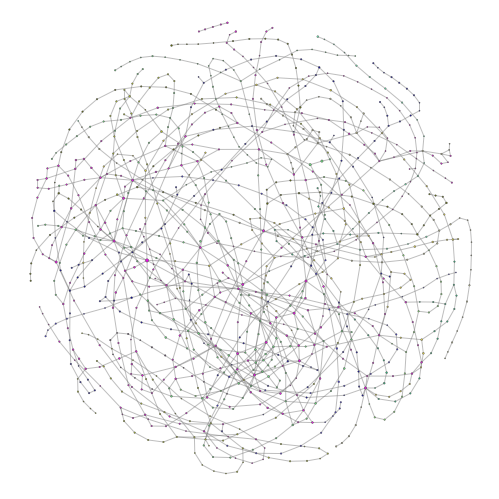

In [356]:
# now let's create a test graph:

test_G = nx.Graph()
test_G = nx.from_pandas_edgelist(station_node_pd, 'station_cd1', 'station_cd2', edge_attr=True)

for k, v in test_G.nodes(data=True):
    v['group'] = line_color[station_node_pd[(station_node_pd['station_cd1'] == k) | (station_node_pd['station_cd2'] == k)].iloc[0, 5]]

for n, data in test_G.nodes(data=True):
    sta = passenger_survey_pd[passenger_survey_pd['station_id'] == n]
    if len(sta) > 0:
        sta_mean = sta[['2013', '2014', '2015', '2016', '2017', '2018', '2019']].values.mean()
        if sta_mean < 10000:
            data['size'] = 1
        elif sta_mean < 100000:
            data['size'] = 2
        elif sta_mean < 500000:
            data['size'] = 3
        else:
            data['size'] = 5
    # elif not station_node_pd[station_node_pd['station_cd2'] == n].empty:
    #     sta = passenger_survey_pd[passenger_survey_pd['station_cd2'] == n]
    #     if len(sta) > 0:
    #         sta_mean = sta[['2013', '2014', '2015', '2016', '2017', '2018', '2019']].values.mean()
    #         if sta_mean < 10000:
    #             data['size'] = 1
    #         elif sta_mean < 100000:
    #             data['size'] = 2
    #         elif sta_mean < 500000:
    #             data['size'] = 3
    #         else:
    #             data['size'] = 5
    else:
        data['size'] = 1
    if n == 725: #Shibuya id is 725
        data['size'] = 10
        print(n, data)
test_return, test_config = nw.visualize(test_G, plot_in_cell_below=True)
nw.draw_netwulf(test_return, test_config)


# print(test_G.edges(data=True))

In [ ]:
# let's look at the original graph:

import torch

A = nx.adjacency_matrix(G)
a = n
torch_A = torch.tensor(A.todense(), dtype=torch.float)
torch_A

tensor([[0., 1., 0.,  ..., 0., 0., 0.],
        [1., 0., 1.,  ..., 0., 0., 0.],
        [0., 1., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 1., 0.],
        [0., 0., 0.,  ..., 1., 0., 1.],
        [0., 0., 0.,  ..., 0., 1., 0.]])

 Getting started with the GNN implementations:

In [358]:
import torch
from torch import nn
from torch_geometric.nn import GCNConv


class GCN(nn.Module):
    def __init__(self, in_features, out_features):
        super(GCN, self).__init__()
        torch.manual_seed(0)
        A = torch.tensor(nx.adjacency_matrix(G).todense())
        A = A + torch.eye(A.size(0))  # Add self-loops
        D = torch.diag(torch.sum(A, dim=1))
        D_inv_sqrt = torch.sqrt(torch.inverse(D))
        self.A_hat = torch.matmul(torch.matmul(D_inv_sqrt, A), D_inv_sqrt)  # Symmetric normalization
        self.layer_1 = nn.Linear(in_features, in_features)
        self.layer_2 = nn.Linear(in_features, out_features)
    
    def forward(self, x):
        x = torch.matmul(self.A_hat, x)
        x = self.layer_1(x)
        x = torch.relu(x)
        x = self.layer_2(x)
        return x

In [359]:
model = GCN(in_features=16, out_features=2)
print(model)

GCN(
  (layer_1): Linear(in_features=16, out_features=16, bias=True)
  (layer_2): Linear(in_features=16, out_features=2, bias=True)
)


In [360]:
# Get node ordering from graph G — this is the order the adjacency matrix uses
node_order = list(G.nodes())
print(f"Node order: {node_order[-10:]}...")  # Print first 10 nodes to verify

# Aggregate passenger survey by station_id (handles duplicate rows per station)
survey_filtered = matching_passenger_survey_pd[matching_passenger_survey_pd['station_id'].isin(node_order)]
survey_agg = survey_filtered.groupby('station_id')[['2013','2014','2015','2016','2017','2018','2019']].mean()
print(f"Unique stations in survey after aggregation: {len(survey_agg)}")

Node order: [121, 1007, 565, 1510, 890, 790, 889, 1714, 674, 653]...
Unique stations in survey after aggregation: 1106


In [361]:
#one hot encoding for line and operator

all_operators = sorted(station_node_pd['operator'].unique())
all_lines = sorted(station_node_pd['line'].unique())

node_operator_df = pd.DataFrame(0, index=node_order, columns=all_operators)
node_line_df = pd.DataFrame(0, index=node_order, columns=all_lines)

for _, row in station_node_pd.iterrows():
    for node_col in ['station_cd1', 'station_cd2']:
        node = row[node_col]
        if node in node_operator_df.index:
            node_operator_df.loc[node, row['operator']] = 1
        if node in node_line_df.index:
            node_line_df.loc[node, row['line']] = 1

operator_features = torch.tensor(node_operator_df.values, dtype=torch.float)
line_features = torch.tensor(node_line_df.values, dtype=torch.float)

In [362]:
# Reorder features to match graph node ordering
train_x = torch.tensor(survey_agg.loc[node_order][['2013', '2014', '2015', '2016', '2017']].to_numpy(), dtype=torch.float)
train_x = torch.cat([train_x, operator_features, line_features], dim=1)  # Concatenate all features
train_y = torch.tensor(survey_agg.loc[node_order][['2018']].to_numpy(), dtype=torch.float)

print(f"train_x shape: {train_x.shape}, train_y shape: {train_y.shape}")
train_x, train_y

train_x shape: torch.Size([1106, 121]), train_y shape: torch.Size([1106, 1])


(tensor([[0.0655, 0.0679, 0.0690,  ..., 0.0000, 0.0000, 0.0000],
         [0.1026, 0.1035, 0.1044,  ..., 0.0000, 0.0000, 0.0000],
         [0.1075, 0.1100, 0.1118,  ..., 0.0000, 0.0000, 0.0000],
         ...,
         [0.0022, 0.0022, 0.0023,  ..., 0.0000, 1.0000, 0.0000],
         [0.0058, 0.0054, 0.0060,  ..., 0.0000, 1.0000, 0.0000],
         [0.0033, 0.0034, 0.0035,  ..., 0.0000, 1.0000, 0.0000]]),
 tensor([[0.0820],
         [0.1111],
         [0.1223],
         ...,
         [0.0026],
         [0.0065],
         [0.0039]]))

In [363]:
# Use same node_order and survey_agg from above
test_x = torch.tensor(survey_agg.loc[node_order][['2014', '2015', '2016', '2017', '2018']].to_numpy(), dtype=torch.float)
test_x = torch.cat([test_x, operator_features, line_features], dim=1)  # Concatenate all features
test_y = torch.tensor(survey_agg.loc[node_order][['2019']].to_numpy(), dtype=torch.float)

print(f"test_x shape: {test_x.shape}, test_y shape: {test_y.shape}")
# Verify train and test inputs are different
print(f"train_x and test_x are identical: {torch.equal(train_x, test_x)}")

test_x shape: torch.Size([1106, 121]), test_y shape: torch.Size([1106, 1])
train_x and test_x are identical: False


In [370]:
model = GCN(in_features=train_x.shape[1], out_features=train_y.shape[1])
criterion = nn.functional.l1_loss
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Convert graph to proper edge_index format: [2, num_edges] LongTensor
adj = nx.adjacency_matrix(G)
rows, cols = adj.nonzero()
edge_index = torch.tensor(np.stack([rows, cols]), dtype=torch.long)
print(f"edge_index shape: {edge_index.shape} (expected [2, num_edges])")

def train(x, y):
    model.train()
    optimizer.zero_grad()
    out = model(x)
    loss = criterion(out, y)
    loss.backward()
    optimizer.step()
    return loss

edge_index shape: torch.Size([2, 2570]) (expected [2, num_edges])


In [371]:

for epoch in range(500):
    loss = train(train_x, train_y)
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.item():.10f}")

Epoch 20, Loss: 0.0152518665
Epoch 40, Loss: 0.0119771622
Epoch 60, Loss: 0.0107982270
Epoch 80, Loss: 0.0098172557
Epoch 100, Loss: 0.0092237471
Epoch 120, Loss: 0.0087999236
Epoch 140, Loss: 0.0081223389
Epoch 160, Loss: 0.0075768442
Epoch 180, Loss: 0.0077623441
Epoch 200, Loss: 0.0067857667
Epoch 220, Loss: 0.0068822145
Epoch 240, Loss: 0.0064714053
Epoch 260, Loss: 0.0065713762
Epoch 280, Loss: 0.0061464901
Epoch 300, Loss: 0.0060378150
Epoch 320, Loss: 0.0053009205
Epoch 340, Loss: 0.0057443646
Epoch 360, Loss: 0.0054861517
Epoch 380, Loss: 0.0063678827
Epoch 400, Loss: 0.0061380900
Epoch 420, Loss: 0.0052717226
Epoch 440, Loss: 0.0048498372
Epoch 460, Loss: 0.0046311379
Epoch 480, Loss: 0.0043990142
Epoch 500, Loss: 0.0041975388


In [372]:
model.eval()
with torch.no_grad():
    train_out = model(train_x)
    train_loss = criterion(train_out, train_y)
    print(f"Train MAE: {train_loss.item():.5f}")

    test_out = model(test_x)
    test_loss = criterion(test_out, test_y)
    print(f"Test MAE: {test_loss.item():.5f}")

    # Show sample predictions to verify they differ
    print(f"\nSample predictions (first 5 nodes):")
    print(f"Train pred: {train_out[:5].squeeze().tolist()}")
    print(f"Train true: {train_y[:5].squeeze().tolist()}")
    print(f"Test pred:  {test_out[:5].squeeze().tolist()}")
    print(f"Test true:  {test_y[:5].squeeze().tolist()}")

    MAE_top_10 = torch.mean(torch.abs(test_out[:10] - test_y[:10]))
    print(f"MAE for top 10 nodes: {MAE_top_10.item():.5f}")


    print("--------------------------------\n")
    train_out_orig = train_out * (global_max - global_min) + global_min
    train_y_orig = train_y * (global_max - global_min) + global_min
    test_out_orig = test_out * (global_max - global_min) + global_min
    test_y_orig = test_y * (global_max - global_min) + global_min
    torch_row_maxs = torch.tensor(row_maxs.to_numpy(), dtype=torch.float).unsqueeze(1)  # Shape [num_nodes, 1]
    torch_row_mins = torch.tensor(row_mins.to_numpy(), dtype=torch.float).unsqueeze(1)  # Shape [num_nodes, 1]
    # train_out_orig = train_out * (torch_row_maxs - torch_row_mins) + torch_row_mins
    # train_y_orig = train_y * (torch_row_maxs - torch_row_mins) + torch_row_mins
    # test_out_orig = test_out * (torch_row_maxs - torch_row_mins) + torch_row_mins
    # test_y_orig = test_y * (torch_row_maxs - torch_row_mins) + torch_row_mins

    print(f"Train MAE: {criterion(train_out_orig, train_y_orig).item():.2f}")
    print(f"Test MAE:  {criterion(test_out_orig, test_y_orig).item():.2f}")

    Absolute_MAE_top_10 = torch.mean(torch.abs(test_out_orig[:10] - test_y_orig[:10]))
    print(f"MAE for top 10 nodes (original scale): {Absolute_MAE_top_10.item():.2f}")
    Absolute_MAE_top_100 = torch.mean(torch.abs(test_out_orig[:100] - test_y_orig[:100]))
    print(f"MAE for top 100 nodes (original scale): {Absolute_MAE_top_100.item():.2f}")
    Absolute_MAE_bottom_100 = torch.mean(torch.abs(test_out_orig[-100:] - test_y_orig[-100:]))
    print(f"MAE for bottom 100 nodes (original scale): {Absolute_MAE_bottom_100.item():.2f}")

Train MAE: 0.00601
Test MAE: 0.00586

Sample predictions (first 5 nodes):
Train pred: [0.10033351927995682, 0.11597862839698792, 0.13144853711128235, 0.1331118941307068, 0.5295865535736084]
Train true: [0.08195573836565018, 0.11108207702636719, 0.12231184542179108, 0.09830205887556076, 0.5911812782287598]
Test pred:  [0.09818078577518463, 0.11583413928747177, 0.13063804805278778, 0.12988512217998505, 0.5185278654098511]
Test true:  [0.08195573836565018, 0.11091522127389908, 0.12242639809846878, 0.09779485315084457, 0.6400741934776306]
MAE for top 10 nodes: 0.04023
--------------------------------

Train MAE: 25380.99
Test MAE:  24753.84
MAE for top 10 nodes (original scale): 169975.78
MAE for top 100 nodes (original scale): 45597.18
MAE for bottom 100 nodes (original scale): 15998.66


In [367]:
print(torch.Tensor(row_maxs.to_numpy()))

tensor([0.0433, 0.0006, 0.0025,  ..., 0.0000, 0.0132, 0.0072])


In [368]:
num_lines = station_node_pd['line'].nunique()
print(f"Number of unique lines: {num_lines}")

num_operators = station_node_pd['operator'].nunique()
print(f"Number of unique operators: {num_operators}")

Number of unique lines: 95
Number of unique operators: 21


In [369]:
# check for reverse duplicate edges in station_node_pd
# note that they are not a problem for building the adjacency, just in case they have different distances etc...
reverse_duplicates = station_node_pd.merge(station_node_pd, left_on=['station_cd1', 'station_cd2'], right_on=['station_cd2', 'station_cd1'], how='inner')
print(f"Number of reverse duplicate edges: {len(reverse_duplicates)}")

Number of reverse duplicate edges: 62


In [ ]:
from torch_geometric.data import Data
from torch_geometric.utils import from_networkx
x = torch.tensor(survey_agg.loc[node_order][['2013', '2014', '2015', '2016', '2017', '2018']].to_numpy(), dtype=torch.float)
x = torch.cat([x, operator_features, line_features], dim=1)  # Concatenate all features
y = torch.tensor(survey_agg.loc[node_order][['2019']].to_numpy(), dtype=torch.float)


data = from_networkx(G)
data.x = x
data.y = y
data.edge_index

tensor([[   0,    0,    0,  ..., 1104, 1105, 1105],
        [   1,   29,    3,  ..., 1105, 1104,  633]])

In [ ]:
# THIS CELL VERIFIES THAT THE NODE ORDERING IN from_networkx MATCHES THE node_order USED FOR FEATURES AND LABELS, AND THAT edge_index CORRECTLY REFLECTS THE GRAPH STRUCTURE

# 1. Confirm from_networkx uses the same node ordering
mapping = {node: i for i, node in enumerate(G.nodes())}
assert list(mapping.keys()) == node_order, "Node order mismatch!"

# 2. Spot-check: pick a node with known neighbors and verify edge_index
test_node = node_order[0]
test_idx = mapping[test_node]
expected_neighbors = set(mapping[n] for n in G.neighbors(test_node))
actual_neighbors = set(data.edge_index[1, data.edge_index[0] == test_idx].tolist())
assert expected_neighbors == actual_neighbors, f"Edge mismatch for node {test_node}"

# 3. Verify edge count matches
assert data.edge_index.shape[1] == 2 * G.number_of_edges(), \
    f"Edge count mismatch: {data.edge_index.shape[1]} vs {2 * G.number_of_edges()}"
# (factor of 2 because PyG stores both directions for undirected graphs)

# 4. Verify feature matrix shape matches node count
assert data.x.shape[0] == len(node_order), "Feature row count != number of nodes"
assert data.y.shape[0] == len(node_order), "Label row count != number of nodes"

# 5. Verify a specific station's features match
sample_station = node_order[5]
expected_vals = survey_agg.loc[sample_station][['2013','2014','2015','2016','2017','2018']].values
assert np.allclose(data.x[5, :6].numpy(), expected_vals), "Feature values don't match for sample node"

print("All checks passed — node ordering and edge_index are aligned.")

All checks passed — node ordering and edge_index are aligned.


In [403]:
#testing splits:

dataset_key = "tokyo_railway"
seed = 0
split_path = f"splits/{dataset_key}_split_0.6_0.2_{seed}.npz"
path = "/Users/denizalkan/Desktop/Academic/Cambridge/L65 Geometric Deep Learning/GDL Project/PolySheafNeuralNetworks-RailwayPassengers/splits/tokyo_railway_split_0.6_0.2_0.npz"


with np.load(path) as f:
    train_mask = f["train_mask"]
    val_mask   = f["val_mask"]
    test_mask  = f["test_mask"]

data.train_mask = torch.tensor(train_mask, dtype=torch.bool)
data.val_mask = torch.tensor(val_mask, dtype=torch.bool)
data.test_mask = torch.tensor(test_mask, dtype=torch.bool)

In [406]:
import torch.nn.functional as F
def train_with_masking(model, data, optimizer):
    model.train()
    optimizer.zero_grad()
    out = model(data.x)[data.train_mask]
    loss = F.l1_loss(out.squeeze(-1), data.y[data.train_mask].float())
    loss.backward()
    optimizer.step()
    return loss

def test_with_masking(model, data):
    model.eval()
    with torch.no_grad():
        preds = model(data.x)
        # Evaluate on test nodes
        losses = []
        for mask in [data.train_mask, data.val_mask, data.test_mask]:
            pred = preds[mask].squeeze(-1)
            loss = F.l1_loss(pred, data.y[mask].float()).item()
            losses.append(loss)
        return losses

model = GCN(in_features=data.x.shape[1], out_features=data.y.shape[1])
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
for epoch in range(500):
    loss = train_with_masking(model, data, optimizer)
    if (epoch + 1) % 20 == 0:
        train_loss, val_loss, test_loss = test_with_masking(model, data)
        print(f"Epoch {epoch+1}, Train Loss: {train_loss:.10f}, Val Loss: {val_loss:.10f}, Test Loss: {test_loss:.10f}")

/var/folders/xj/3fjpg0hj2vb2c30k0v8tfmrh0000gn/T/ipykernel_88731/2433894767.py:6: UserWarning: Using a target size (torch.Size([663, 1])) that is different to the input size (torch.Size([663])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss = F.l1_loss(out.squeeze(-1), data.y[data.train_mask].float())
/var/folders/xj/3fjpg0hj2vb2c30k0v8tfmrh0000gn/T/ipykernel_88731/2433894767.py:19: UserWarning: Using a target size (torch.Size([663, 1])) that is different to the input size (torch.Size([663])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss = F.l1_loss(pred, data.y[mask].float()).item()
/var/folders/xj/3fjpg0hj2vb2c30k0v8tfmrh0000gn/T/ipykernel_88731/2433894767.py:19: UserWarning: Using a target size (torch.Size([221, 1])) that is different to the input size (torch.Size([221])). This will likely lead to incorrect results due to broadcasting. Please ensure they h

Epoch 20, Train Loss: 0.0141861187, Val Loss: 0.0193619803, Test Loss: 0.0174255800
Epoch 40, Train Loss: 0.0128171286, Val Loss: 0.0180464014, Test Loss: 0.0159893632
Epoch 60, Train Loss: 0.0126923174, Val Loss: 0.0180692244, Test Loss: 0.0159822162
Epoch 80, Train Loss: 0.0126581322, Val Loss: 0.0179421827, Test Loss: 0.0158518460
Epoch 100, Train Loss: 0.0126511296, Val Loss: 0.0179576706, Test Loss: 0.0158660784
Epoch 120, Train Loss: 0.0126488861, Val Loss: 0.0179572664, Test Loss: 0.0158646610
Epoch 140, Train Loss: 0.0126474639, Val Loss: 0.0179575477, Test Loss: 0.0158636328
Epoch 160, Train Loss: 0.0126465401, Val Loss: 0.0179574993, Test Loss: 0.0158627927
Epoch 180, Train Loss: 0.0126458593, Val Loss: 0.0179565996, Test Loss: 0.0158610772
Epoch 200, Train Loss: 0.0126453498, Val Loss: 0.0179556776, Test Loss: 0.0158595815
Epoch 220, Train Loss: 0.0126449550, Val Loss: 0.0179549176, Test Loss: 0.0158585329
Epoch 240, Train Loss: 0.0126446355, Val Loss: 0.0179543551, Test Los